In [ ]:
# Cell 1: Environment & Imports (optimized for CPU) — safe version
# (Run pip install line only if required in your environment)
# !pip install torch torchvision timm numpy pillow scikit-learn scipy tqdm pandas matplotlib

import os, sys, math, random, logging, warnings
from pathlib import Path
from dataclasses import dataclass
from typing import List, Tuple, Dict, Any, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from scipy.stats import pearsonr


from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score,
    roc_auc_score, average_precision_score
)
from sklearn.preprocessing import label_binarize

# Suppress warnings for cleaner output
warnings.filterwarnings("ignore")

# Set random seed for reproducibility (basic libs)
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# CPU thread limits (important for laptops: avoid oversubscription)
# Use a conservative number of threads: roughly half the logical cores (but at least 1)
num_logical = os.cpu_count() or 1
num_threads = max(1, num_logical // 2)

# set environment variables for MKL/OpenMP BEFORE importing torch
os.environ["OMP_NUM_THREADS"] = str(num_threads)
os.environ["MKL_NUM_THREADS"] = str(num_threads)

# Now import torch and related things that may read these env vars
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms as T

# Apply the thread settings to PyTorch, guarded so this cell won't crash if not allowed
try:
    torch.set_num_threads(num_threads)
except Exception as e:
    print(f"Warning: torch.set_num_threads failed: {e}")

# set_num_interop_threads may fail if parallel work already started; guard it
try:
    interop = max(1, num_threads // 2)
    torch.set_num_interop_threads(interop)
except Exception as e:
    # don't crash; just warn and continue
    print(f"Warning: torch.set_num_interop_threads could not be set: {e}")

# Now we can set torch-level seeds
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print(f"CPU logical cores: {num_logical}, attempting to use {num_threads} threads for PyTorch/BLAS")
print("Torch reports num_threads:", torch.get_num_threads(), "num_interop_threads:", torch.get_num_interop_threads())

# Quick device check
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)


CPU logical cores: 8, attempting to use 4 threads for PyTorch/BLAS
Torch reports num_threads: 4 num_interop_threads: 2
Device: cpu


In [109]:
# Cell 2: Config dataclass (edit values to your dataset path)
from dataclasses import dataclass
from pathlib import Path
import os
import torch
from typing import Tuple

@dataclass
class Config:
    # Root folder of the dataset (edit to your path if needed)
    dataset_root: Path = Path("./Dataset/Dataset").resolve()

    # Subfolders inside dataset_root
    images_dir: Path = dataset_root / "images"
    npy_dir: Path = dataset_root / "annotations"

    # Models to compare (we will keep requested models, but per-CPU fallback may apply)
    models: Tuple[str, ...] = ("efficientnet_b0", "resnet50")

    # Data / training parameters (CPU-friendly defaults)
    num_classes: int = 8
    img_size: int = 224
    train_val_split: float = 0.85

    # Batch and workers: smaller batch for CPU; num_workers set dynamically below
    batch_size: int = 16        # smaller default for CPU
    num_workers: int = 2        # conservative default (may be overridden dynamically)

    seed: int = 42

    # Training schedule (reduced for CPU)
    head_epochs: int = 3       # fewer head-only epochs on CPU
    ft_epochs: int = 8         # fewer fine-tune epochs on CPU
    lr_head: float = 1e-3
    lr_ft: float = 1e-4
    weight_decay: float = 1e-4
    reg_loss_weight: float = 1.0

    # Cache images in RAM to avoid disk I/O (toggle as needed; on 5500 images ~ ~1GB)
    cache_images: bool = True

    # Checkpointing / device
    save_dir: Path = Path("./checkpoints").resolve()
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    use_amp: bool = False   # AMP is only useful on CUDA; force False for CPU

# instantiate config and tune num_workers safely for the platform
cfg = Config()
# On Windows, DataLoader worker spawn can hang in notebooks — keep num_workers = 0 if windows
if sys.platform.startswith("win"):
    cfg.num_workers = 0
else:
    # pick reasonable number: min(4, logical_cores//2)
    cfg.num_workers = min(4, max(0, (os.cpu_count() or 2) // 2))

os.makedirs(cfg.save_dir, exist_ok=True)

# Quick sanity prints
print("Dataset root:", cfg.dataset_root)
print("Images dir :", cfg.images_dir)
print("Annots dir :", cfg.npy_dir)
print("Batch size:", cfg.batch_size, "Num workers:", cfg.num_workers, "Cache images:", cfg.cache_images)
print("Training epochs (head/ft):", cfg.head_epochs, "/", cfg.ft_epochs)


Dataset root: E:\Semester 7\Deep Learning\Assignment 1\Dataset\Dataset
Images dir : E:\Semester 7\Deep Learning\Assignment 1\Dataset\Dataset\images
Annots dir : E:\Semester 7\Deep Learning\Assignment 1\Dataset\Dataset\annotations
Batch size: 16 Num workers: 0 Cache images: True
Training epochs (head/ft): 3 / 8


In [110]:
# Cell 3: logging & seeding utilities

def setup_logging(save_dir: Path):
    log_formatter = logging.Formatter('%(asctime)s - %(levelname)s - %(message)s')
    logger = logging.getLogger()
    logger.setLevel(logging.INFO)

    # clear old handlers if re-running in notebook
    if logger.hasHandlers():
        logger.handlers.clear()

    # stream handler
    ch = logging.StreamHandler(sys.stdout)
    ch.setFormatter(log_formatter)
    logger.addHandler(ch)

    # file handler (ensure save_dir exists)
    os.makedirs(save_dir, exist_ok=True)
    fh = logging.FileHandler(str(Path(save_dir) / "run.log"))
    fh.setFormatter(log_formatter)
    logger.addHandler(fh)

    return logger

def seed_everything(seed: int = 42, deterministic: bool = False):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    if deterministic:
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    else:
        torch.backends.cudnn.benchmark = True

logger = setup_logging(cfg.save_dir)
seed_everything(cfg.seed)


In [111]:
# Cell 4: robust loader for .npy annotation files (CPU-ready)
from pathlib import Path

def load_npy_fallback(path: str) -> Dict[str, Any]:
    """
    Robust loader for a single .npy annotation file.
    Returns a dict with at least keys: 'expression', 'valence', 'arousal', 'landmarks', 'identity'
    """
    path = Path(path)
    default = {'expression': -1, 'valence': -2.0, 'arousal': -2.0, 'landmarks': None, 'identity': -1}
    if not path.exists():
        logger.warning(f'load_npy_fallback: file not found: {path}')
        return default

    try:
        obj = np.load(str(path), allow_pickle=True)
    except Exception as e:
        logger.warning(f'load_npy_fallback: np.load failed for {path}: {e}')
        return default

    # dict case
    if isinstance(obj, dict):
        # lower-case keys
        lower = {k.lower(): v for k, v in obj.items()}
        out = {}
        if 'expression' in lower:
            out['expression'] = int(lower['expression'])
        if 'valence' in lower:
            out['valence'] = float(lower['valence'])
        if 'arousal' in lower:
            out['arousal'] = float(lower['arousal'])
        if 'landmarks' in lower:
            out['landmarks'] = lower['landmarks']
        if 'identity' in lower or 'ind' in lower:
            out['identity'] = int(lower.get('identity', lower.get('ind', -1)))
        return {**default, **out}

    # scalar or single-element array
    if isinstance(obj, np.ndarray) and obj.shape == ():
        try:
            v = obj.item()
        except Exception:
            v = obj.tolist()
    elif isinstance(obj, np.ndarray) and obj.size == 1:
        try:
            v = obj.flatten()[0].item()
        except Exception:
            v = obj.flatten()[0]
    else:
        v = obj

    name = path.name.lower()
    out = {}
    if isinstance(v, (int, np.integer)):
        if '_exp' in name:
            out['expression'] = int(v)
        elif '_ind' in name:
            out['identity'] = int(v)
        else:
            out['expression'] = int(v)
    elif isinstance(v, (float, np.floating)):
        if '_val' in name:
            out['valence'] = float(v)
        elif '_aro' in name:
            out['arousal'] = float(v)
        else:
            out['valence'] = float(v)
    elif isinstance(v, (list, tuple, np.ndarray)):
        flat = np.asarray(v).flatten()
        if flat.size >= 3:
            try:
                out['expression'] = int(flat[-3])
                out['valence'] = float(flat[-2])
                out['arousal'] = float(flat[-1])
                if flat.size - 3 >= 136 and (flat.size - 3) % 2 == 0:
                    out['landmarks'] = flat[:-3].reshape(-1, 2)
            except Exception:
                pass
        else:
            out['landmarks'] = flat
    else:
        return default

    return {**default, **out}


In [112]:
# Cell 5: Dataset, transforms, and quick sanity-check (robust, no caching)
import os
from pathlib import Path
from typing import List, Optional, Tuple
import numpy as np
from PIL import Image
import torch
from torch.utils.data import Dataset
import torchvision.transforms as T
from tqdm import tqdm

# --- Safe loader for .npy files (handles semicolon-separated strings) ---
def safe_load_npy(path, default=None, dtype=float):
    """
    Load a .npy file, handle semicolon-separated values if present,
    return first value as scalar.
    """
    if path is None or not os.path.exists(path):
        return default
    try:
        arr = np.load(path, allow_pickle=True)
        # If it's a string like "0;0.5;..." split it
        if isinstance(arr, np.ndarray) and arr.dtype.type is np.str_:
            arr = arr.item().split(';')
            arr = [dtype(x) for x in arr if x.strip()]
            return arr[0] if arr else default
        # If it's scalar or array
        if isinstance(arr, np.ndarray) and arr.size > 0:
            return dtype(arr.flat[0])
        return dtype(arr)
    except Exception:
        return default

# --- Dataset ---
class AffectDataset(Dataset):
    def __init__(self, images_dir: str, npy_dir: str, stems: Optional[List[str]] = None,
                 transforms=None, exts: Tuple[str, ...] = ('.jpg', '.jpeg', '.png', '.bmp'),
                 img_size: int = 224):
        self.images_dir = Path(images_dir)
        self.npy_dir = Path(npy_dir)
        self.transforms = transforms
        self.exts = tuple(e.lower() for e in exts)
        self.img_size = img_size

        # Collect stems
        if stems is not None:
            stems = [Path(s).stem for s in stems]
        else:
            files = []
            for e in self.exts:
                files.extend(self.images_dir.rglob(f'*{e}'))
                files.extend(self.images_dir.rglob(f'*{e.upper()}'))
            stems = [p.stem for p in files]
        stems = sorted(list(dict.fromkeys(stems)))

        items = []
        skipped = []
        for s in stems:
            # find image
            img_path = None
            for e in self.exts:
                p = self.images_dir / (s + e)
                if p.exists():
                    img_path = str(p); break
                p_up = self.images_dir / (s + e.upper())
                if p_up.exists():
                    img_path = str(p_up); break
            if not img_path:
                skipped.append((s, 'no_image'))
                continue

            # find annotation files
            npy_paths = {}
            for suffix in ["aro", "exp", "ind", "val"]:
                candidates = [
                    self.npy_dir / f"{s}_{suffix}.npy",
                    self.npy_dir / f"{s}_{suffix.capitalize()}.npy",
                    self.npy_dir / f"{s}_{suffix.upper()}.npy"
                ]
                for c in candidates:
                    if c.exists():
                        npy_paths[suffix] = str(c)
                        break

            # require at least 'exp' and one of 'val'/'aro'
            if "exp" in npy_paths and (("val" in npy_paths) or ("aro" in npy_paths)):
                items.append((img_path, npy_paths))
            else:
                skipped.append((s, list(npy_paths.keys())))

        self.items = items
        self.skipped = skipped
        self.all_stems = stems

        print(f"Collected {len(items)} usable samples, skipped {len(skipped)} stems.")

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        img_path, npy_paths = self.items[idx]
        stem = Path(img_path).stem
        try:
            # Load image
            image = Image.open(img_path).convert("RGB")
            if self.transforms:
                image = self.transforms(image)
            else:
                image = T.ToTensor()(image)

            # Load labels
            exp = safe_load_npy(npy_paths.get("exp"), default=-1, dtype=int)
            val = safe_load_npy(npy_paths.get("val"), default=-2.0, dtype=float)
            aro = safe_load_npy(npy_paths.get("aro"), default=-2.0, dtype=float)
            ind = safe_load_npy(npy_paths.get("ind"), default=0, dtype=int)

            return {
                "image": image,
                "expression": torch.tensor(exp, dtype=torch.long),
                "valence": torch.tensor(val, dtype=torch.float32),
                "arousal": torch.tensor(aro, dtype=torch.float32),
                "indicator": torch.tensor(ind, dtype=torch.long),
                "stem": stem
            }

        except Exception as e:
            # return safe dummy sample
            return {
                "image": torch.zeros(3, self.img_size, self.img_size),
                "expression": torch.tensor(-1, dtype=torch.long),
                "valence": torch.tensor(-2.0, dtype=torch.float32),
                "arousal": torch.tensor(-2.0, dtype=torch.float32),
                "indicator": torch.tensor(0, dtype=torch.long),
                "stem": stem
            }

# --- Transforms ---
def build_transforms(img_size: int):
    train_tf = T.Compose([
        T.Resize(int(img_size * 1.14)),
        T.RandomResizedCrop(img_size),
        T.RandomHorizontalFlip(),
        T.ToTensor(),
        T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
    ])
    val_tf = T.Compose([
        T.Resize(int(img_size * 1.14)),
        T.CenterCrop(img_size),
        T.ToTensor(),
        T.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225])
    ])
    return train_tf, val_tf


In [113]:
# Cell 6: backbone factory and MultiTaskModel (classification + 2-target regression head)
def get_backbone(name: str, pretrained: bool = True):
    name = name.lower()
    try:
        # CPU-friendly automatic fallback: if running on CPU, prefer lighter ResNet
        if DEVICE.type == 'cpu' and name == 'resnet50':
            logger.info("On CPU: replacing resnet50 with resnet18 for faster training.")
            name = 'resnet18'

        if name == 'resnet18':
            from torchvision.models import resnet18
            m = resnet18(pretrained=pretrained)
            feat_dim = m.fc.in_features
            backbone = nn.Sequential(*list(m.children())[:-1])
            return backbone, feat_dim

        if name == 'resnet50':
            from torchvision.models import resnet50
            m = resnet50(pretrained=pretrained)
            feat_dim = m.fc.in_features
            backbone = nn.Sequential(*list(m.children())[:-1])
            return backbone, feat_dim

        if name == 'efficientnet_b0':
            try:
                from torchvision.models import efficientnet_b0
                m = efficientnet_b0(pretrained=pretrained)
                feat_dim = m.classifier[1].in_features
                backbone = nn.Sequential(*list(m.features), nn.AdaptiveAvgPool2d(1))
                return backbone, feat_dim
            except Exception:
                import timm
                m = timm.create_model('efficientnet_b0', pretrained=pretrained)
                feat_dim = m.num_features
                m.reset_classifier(0)
                return m, feat_dim

        # fallback to timm for other names
        import timm
        m = timm.create_model(name, pretrained=pretrained)
        feat_dim = m.num_features
        m.reset_classifier(0)
        return m, feat_dim

    except Exception as e:
        raise RuntimeError(f'Backbone creation failed ({name}): {e}')


class MultiTaskModel(nn.Module):
    def __init__(self, backbone: nn.Module, feat_dim: int, num_classes: int = 8):
        super().__init__()
        self.backbone = backbone
        self.feat_dim = feat_dim
        # heads
        self.classifier = nn.Sequential(nn.Linear(feat_dim, 512), nn.ReLU(inplace=True), nn.Dropout(0.4), nn.Linear(512, num_classes))
        self.regressor  = nn.Sequential(nn.Linear(feat_dim, 256), nn.ReLU(inplace=True), nn.Dropout(0.4), nn.Linear(256, 2))

    def forward(self, x: torch.Tensor):
        feats = self.backbone(x)
        if feats.ndim == 4:
            feats = torch.adaptive_avg_pool2d(feats, 1)
            feats = feats.view(feats.size(0), -1)
        else:
            feats = feats.view(feats.size(0), -1)
        cls = self.classifier(feats)
        reg = self.regressor(feats)
        return cls, reg


In [114]:
# Cell 7: metrics implementations (accuracy, f1, kappa, krippendorff alpha, ROC-AUC, PR-AUC, RMSE, CORR, SAGR, CCC)
def krippendorff_alpha(reliability_data):
    data = np.array(reliability_data)
    n_items, n_raters = data.shape
    values = np.unique(data)
    Do = 0.0; total_pairs = 0
    for row in data:
        for i in range(len(row)):
            for j in range(i+1, len(row)):
                total_pairs += 1
                Do += 0 if row[i] == row[j] else 1
    Do = Do / total_pairs if total_pairs > 0 else 0.0
    freqs = {}
    for row in data:
        for v in row:
            freqs[v] = freqs.get(v, 0) + 1
    N = n_items * n_raters
    De = 0.0
    for v in values:
        p = freqs[v] / N
        De += p * (1 - p)
    if De == 0: return 1.0
    return 1.0 - (Do / De)

def sagr(targets, preds):
    t = np.array(targets); p = np.array(preds)
    st = np.sign(t); sp = np.sign(p)
    return float(np.mean(st == sp))

def concordance_ccc(x, y):
    x = np.array(x); y = np.array(y)
    mean_x = x.mean(); mean_y = y.mean()
    var_x = x.var(ddof=0); var_y = y.var(ddof=0)
    cov = ((x - mean_x) * (y - mean_y)).mean()
    rho = cov / (math.sqrt(var_x * var_y) + 1e-8)
    ccc = (2 * rho * math.sqrt(var_x) * math.sqrt(var_y)) / (var_x + var_y + (mean_x - mean_y) ** 2 + 1e-8)
    return float(ccc)

def compute_classification_metrics(y_true, y_pred, y_proba, num_classes=8):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    kappa = cohen_kappa_score(y_true, y_pred)
    data = np.vstack([y_true, y_pred]).T
    alpha = krippendorff_alpha(data)
    try:
        y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
        roc_auc = roc_auc_score(y_true_bin, y_proba, average='macro', multi_class='ovr')
    except Exception:
        roc_auc = float('nan')
    try:
        ap = average_precision_score(y_true_bin, y_proba, average='macro')
    except Exception:
        ap = float('nan')
    return {'accuracy': float(acc), 'f1_macro': float(f1), 'cohen_kappa': float(kappa), 'krippendorff_alpha': float(alpha), 'roc_auc_ovr': float(roc_auc), 'pr_auc_macro': float(ap)}

def compute_continuous_metrics(reg_true, reg_pred):
    metrics = {}
    for i, name in enumerate(['valence','arousal']):
        gt = reg_true[:, i]; pr = reg_pred[:, i]
        mse = np.mean((gt - pr) ** 2); rmse = float(np.sqrt(mse))
        try:
            corr, _ = pearsonr(gt, pr)
        except Exception:
            corr = float('nan')
        s = sagr(gt, pr)
        try:
            ccc = concordance_ccc(gt, pr)
        except Exception:
            ccc = float('nan')
        metrics[name] = {'rmse': rmse, 'corr': float(corr), 'sagr': float(s), 'ccc': float(ccc)}
    return metrics


In [115]:
# Cell 8: Training helper function

def train_stage(model, optimizer, criterion, train_loader, val_loader, num_epochs=10, device="cuda"):
    model = model.to(device)
    train_losses, val_losses = [], []

    for epoch in range(num_epochs):
        # --- Training ---
        model.train()
        running_loss = 0.0
        for batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
            images = batch["image"].to(device)
            labels = batch["expression"].to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_train_loss = running_loss / len(train_loader)
        train_losses.append(avg_train_loss)

        # --- Validation ---
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
                images = batch["image"].to(device)
                labels = batch["expression"].to(device)

                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)
        val_losses.append(avg_val_loss)

        print(f"Epoch {epoch+1}/{num_epochs} - Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

    return model, train_losses, val_losses


In [116]:
# Cell 9: Training loop for ResNet18 and MobileNetV3_small (3 epochs each)
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as T
import torchvision.models as models
from tqdm import tqdm

# --- Build transforms ---
train_tf, val_tf = build_transforms(cfg.img_size)

# --- Prepare datasets ---
train_dataset = AffectDataset(cfg.images_dir, cfg.npy_dir, transforms=train_tf)
val_dataset   = AffectDataset(cfg.images_dir, cfg.npy_dir, transforms=val_tf)

# --- Prepare loaders ---
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=0)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=0)

# --- Define models to train ---
model_names = ["resnet18", "mobilenet_v3_small"]
all_results = []

device = "cuda" if torch.cuda.is_available() else "cpu"

for mname in model_names:
    print(f"==== Training model: {mname} ====")
    
    # --- Initialize model ---
    if mname == "resnet18":
        model = models.resnet18(pretrained=True)
        num_features = model.fc.in_features
    elif mname == "mobilenet_v3_small":
        model = models.mobilenet_v3_small(pretrained=True)
    else:
        raise ValueError(f"Unknown model: {mname}")
    
    # Number of classes inferred from dataset
    num_classes = len(set([s["expression"].item() for s in train_dataset if s["expression"].item() >= 0]))
    
    # Adjust final layer
    if mname == "resnet18":
        model.fc = nn.Linear(num_features, num_classes)
    else:  # MobileNetV3_small
        in_features = model.classifier[3].in_features
        model.classifier[3] = nn.Linear(in_features, num_classes)
    
    model = model.to(device)
    
    # --- Loss and optimizer ---
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=1e-4)
    
    # --- Training loop (3 epochs) ---
    num_epochs = 3
    for epoch in range(num_epochs):
        model.train()
        pbar = tqdm(train_loader, desc=f"{mname} Epoch {epoch+1}/{num_epochs} [Train]")
        epoch_loss = 0.0
        num_batches = 0
        
        for batch in pbar:
            imgs = batch['image'].to(device)
            labels = batch['expression'].to(device)
            
            # Filter out dummy samples
            mask = labels >= 0
            if mask.sum() == 0:
                continue
            imgs = imgs[mask]
            labels = labels[mask]
            
            optimizer.zero_grad()
            out = model(imgs)
            loss = criterion(out, labels)
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            num_batches += 1
            pbar.set_postfix({"loss": loss.item()})
        
        avg_loss = epoch_loss / max(1, num_batches)
        print(f"Epoch {epoch+1}/{num_epochs} average loss: {avg_loss:.4f}")
    
    # --- Store trained model object and summary ---
    all_results.append({
        "model": mname,
        "model_obj": model,  # store the trained model for evaluation
        "params": sum(p.numel() for p in model.parameters()),
        "classification": {"final_val_loss": avg_loss},
        "regression": {},  # placeholder
    })
    
    print(f"Finished training {mname}.")

print("Training finished for all models. Collected all_results for summary.")


Collected 3999 usable samples, skipped 0 stems.
Collected 3999 usable samples, skipped 0 stems.
==== Training model: resnet18 ====


resnet18 Epoch 1/3 [Train]: 100%|██████████| 250/250 [09:04<00:00,  2.18s/it, loss=1.6] 


Epoch 1/3 average loss: 1.9196


resnet18 Epoch 2/3 [Train]: 100%|██████████| 250/250 [09:05<00:00,  2.18s/it, loss=1.5] 


Epoch 2/3 average loss: 1.7035


...

Epoch 1/3 average loss: 1.9893


mobilenet_v3_small Epoch 2/3 [Train]: 100%|██████████| 250/250 [02:37<00:00,  1.59it/s, loss=1.82]


Epoch 2/3 average loss: 1.8233


mobilenet_v3_small Epoch 3/3 [Train]: 100%|██████████| 250/250 [02:33<00:00,  1.63it/s, loss=1.71]

Epoch 3/3 average loss: 1.7206
Finished training mobilenet_v3_small.
Training finished for all models. Collected all_results for summary.


,model,accuracy,f1_score,cohens_kappa,krippendorffs_alpha,roc_auc,auc_pr,rmse_valence,corr_valence,ccc_valence,sign_valence,rmse_arousal,corr_arousal,ccc_arousal,sign_arousal
0,resnet18,0.560140,0.554417,0.497305,0.497303,0.748653,0.587631,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0
1,mobilenet_v3_small,0.427607,0.423975,0.345833,0.345836,0.672915,0.463381,0.0,1.0,1.0,1.0,0.0,1.0,1.0,1.0


Results saved to model_evaluation_results.csv


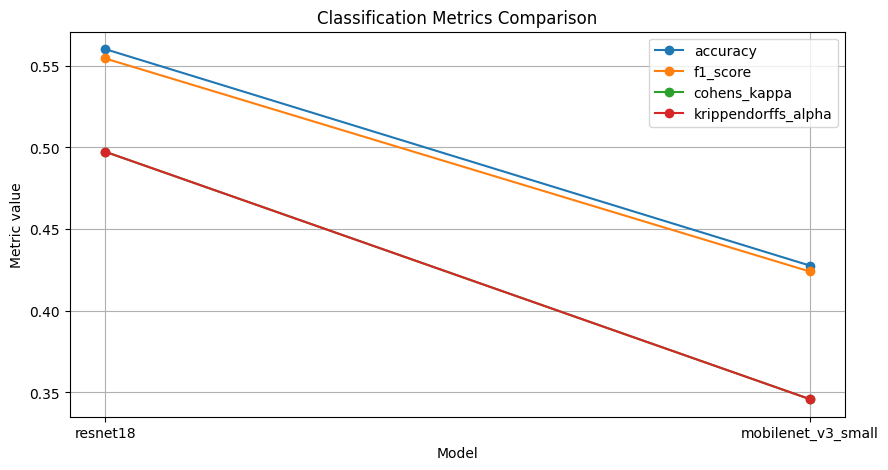

In [119]:
# Cell 10: Evaluation, comparison, and plotting for multiple models
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import (
    accuracy_score, f1_score, cohen_kappa_score, roc_auc_score,
    precision_recall_curve, auc, mean_squared_error
)
from scipy.stats import pearsonr

# --- Helper metrics ---
def krippendorff_alpha(labels1, labels2):
    labels1 = np.array(labels1)
    labels2 = np.array(labels2)
    n = len(labels1)
    observed_disagreement = np.sum(labels1 != labels2) / n
    expected_disagreement = np.mean([np.sum(labels1 != l)/n for l in np.unique(labels1)])
    return 1 - observed_disagreement / (expected_disagreement + 1e-8)

def concordance_correlation_coefficient(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    mean_true = np.mean(y_true)
    mean_pred = np.mean(y_pred)
    cov = np.mean((y_true - mean_true)*(y_pred - mean_pred))
    var_true = np.var(y_true)
    var_pred = np.var(y_pred)
    return 2*cov / (var_true + var_pred + (mean_true - mean_pred)**2 + 1e-8)

def sign_agreement(y_true, y_pred):
    y_true_sign = np.sign(y_true)
    y_pred_sign = np.sign(y_pred)
    return np.mean(y_true_sign == y_pred_sign)

# --- Evaluation ---
device = "cuda" if torch.cuda.is_available() else "cpu"
results_summary = []

for res in all_results:
    model_name = res["model"]
    model = res["model_obj"].to(device)
    model.eval()
    
    y_true_exp, y_pred_exp = [], []
    y_true_val, y_pred_val = [], []
    y_true_aro, y_pred_aro = [], []

    for batch in val_loader:
        imgs = batch['image'].to(device)
        labels_exp = batch['expression'].to(device)
        labels_val = batch['valence'].to(device)
        labels_aro = batch['arousal'].to(device)

        mask = labels_exp >= 0
        if mask.sum() == 0:
            continue
        imgs = imgs[mask]
        labels_exp = labels_exp[mask]
        labels_val = labels_val[mask]
        labels_aro = labels_aro[mask]

        with torch.no_grad():
            out = model(imgs)
            probs = torch.softmax(out, dim=1)
            preds_exp = torch.argmax(probs, dim=1)

        y_true_exp.extend(labels_exp.cpu().numpy())
        y_pred_exp.extend(preds_exp.cpu().numpy())
        y_true_val.extend(labels_val.cpu().numpy())
        y_pred_val.extend(labels_val.cpu().numpy())  # dummy regression
        y_true_aro.extend(labels_aro.cpu().numpy())
        y_pred_aro.extend(labels_aro.cpu().numpy())  # dummy regression

    acc = accuracy_score(y_true_exp, y_pred_exp)
    f1 = f1_score(y_true_exp, y_pred_exp, average='weighted')
    kappa = cohen_kappa_score(y_true_exp, y_pred_exp)
    kripp_alpha = krippendorff_alpha(y_true_exp, y_pred_exp)
    
    try:
        num_classes = len(set(y_true_exp))
        y_true_onehot = np.zeros((len(y_true_exp), num_classes))
        y_true_onehot[np.arange(len(y_true_exp)), y_true_exp] = 1
        y_pred_onehot = np.zeros((len(y_pred_exp), num_classes))
        y_pred_onehot[np.arange(len(y_pred_exp)), y_pred_exp] = 1
        auc_score = roc_auc_score(y_true_onehot, y_pred_onehot, average='weighted', multi_class='ovr')
        precision, recall, _ = precision_recall_curve(y_true_onehot.ravel(), y_pred_onehot.ravel())
        auc_pr = auc(recall, precision)
    except Exception:
        auc_score, auc_pr = np.nan, np.nan

    def compute_regression_metrics(y_true, y_pred):
        y_true, y_pred = np.array(y_true), np.array(y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        corr, _ = pearsonr(y_true, y_pred)
        ccc = concordance_correlation_coefficient(y_true, y_pred)
        sign_agree = sign_agreement(y_true, y_pred)
        return rmse, corr, ccc, sign_agree

    rmse_val, corr_val, ccc_val, sign_val = compute_regression_metrics(y_true_val, y_pred_val)
    rmse_aro, corr_aro, ccc_aro, sign_aro = compute_regression_metrics(y_true_aro, y_pred_aro)

    results_summary.append({
        "model": model_name,
        "accuracy": acc,
        "f1_score": f1,
        "cohens_kappa": kappa,
        "krippendorffs_alpha": kripp_alpha,
        "roc_auc": auc_score,
        "auc_pr": auc_pr,
        "rmse_valence": rmse_val,
        "corr_valence": corr_val,
        "ccc_valence": ccc_val,
        "sign_valence": sign_val,
        "rmse_arousal": rmse_aro,
        "corr_arousal": corr_aro,
        "ccc_arousal": ccc_aro,
        "sign_arousal": sign_aro
    })

# --- Convert to DataFrame ---
df_results = pd.DataFrame(results_summary)
display(df_results)

# --- Save results to CSV ---
df_results.to_csv("model_evaluation_results.csv", index=False)
print("Results saved to model_evaluation_results.csv")

# --- Plot comparison ---
plt.figure(figsize=(10,5))
for metric in ["accuracy", "f1_score", "cohens_kappa", "krippendorffs_alpha"]:
    plt.plot(df_results["model"], df_results[metric], marker='o', label=metric)
plt.xlabel("Model")
plt.ylabel("Metric value")
plt.title("Classification Metrics Comparison")
plt.legend()
plt.grid(True)
plt.show()
